## Context

### Bank Customer Churn Prediction
Customer churn, also known as customer attrition, refers to the phenomenon whereby a customer ceases engagement with a company's services. Studies have shown that acquiring new customers can cost five times more than retaining existing customers. It is little wonder that banks are finding it increasingly important to track and retain existing customers. 

You are a data analyst working in one of the largest bank by assets in SEA. It is the largest payment bank in terms of transaction value. You are tasked to analyze and prevent customers portfolio attrition by creating a predictive model to identify customers with a higher propensity to churn, based on the customers' personal information and past history with the bank.

## Objectives
Based on what you have learnt in the course: 
1. Load the Bank Churn dataset and perform any necessary data preprocessing
2. Perform Exploratory Data Analysis (EDA) on the preprocessed dataset
3. Implement feature selection using suitable statistical techniques
4. Train, validate and evaluate a Supervised Learning model
5. Implement an optimal Supervised Learning model to address specific business needs

## Dataset

You are provided with the following files:
1. bank_churn.csv
2. Data Dictionary - Bank Churn.xlsx

### Step 1: Import Data and Perform Data Preprocessing [5 marks]

#### 1.1 Import packages

In [8]:
# Import the required packages
# To suppress unneccesary warnings
import warnings
warnings.filterwarnings('ignore')

import math
import statistics
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve
from sklearn.preprocessing import StandardScaler

#### 1.2 Load data into DataFrame

In [10]:
# Import bank churn dataset
bank_churn = pd.read_csv('./Data/bank_churn.csv')
bank_churn.head()

,CID,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned
0,634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### 1.3 Drop unnecessary column(s) and encode categorical variables

In [12]:
#check for null values
bank_churn.isnull().sum()

CID                0
CreditScore        0
Country            0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Churned            0
dtype: int64

In [13]:
# Drop customer ID column
bank_churn.drop('CID', axis=1, inplace=True)
bank_churn.head()

,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
# Perform one-hot encoding of the categorical variable
bank_churn['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [15]:
gender_dict = {'Male': 1, 'Female': 0}
bank_churn['Gender'] = bank_churn['Gender'].map(gender_dict)
bank_churn['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [16]:
bank_churn['Country'].value_counts()

Country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [17]:
bank_churn = pd.get_dummies(bank_churn, columns=['Country'], drop_first=True).astype(int)

bank_churn.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned,Country_Germany,Country_Spain
0,619,0,42,2,0,1,1,1,101348,1,0,0
1,608,0,41,1,83807,1,0,1,112542,0,0,1
2,502,0,42,8,159660,3,1,0,113931,1,0,0
3,699,0,39,1,0,2,0,0,93826,0,0,0
4,850,0,43,2,125510,1,1,1,79084,0,0,1


### Step 2: Perform EDA on the dataset [10 marks]

#### 2.1 Check correlation of variables

In [20]:
# Explore correlations of the features
bank_churn.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned,Country_Germany,Country_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304179,-0.014858,-0.010084,0.012798,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304179,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012798,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Churned,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


<Axes: >

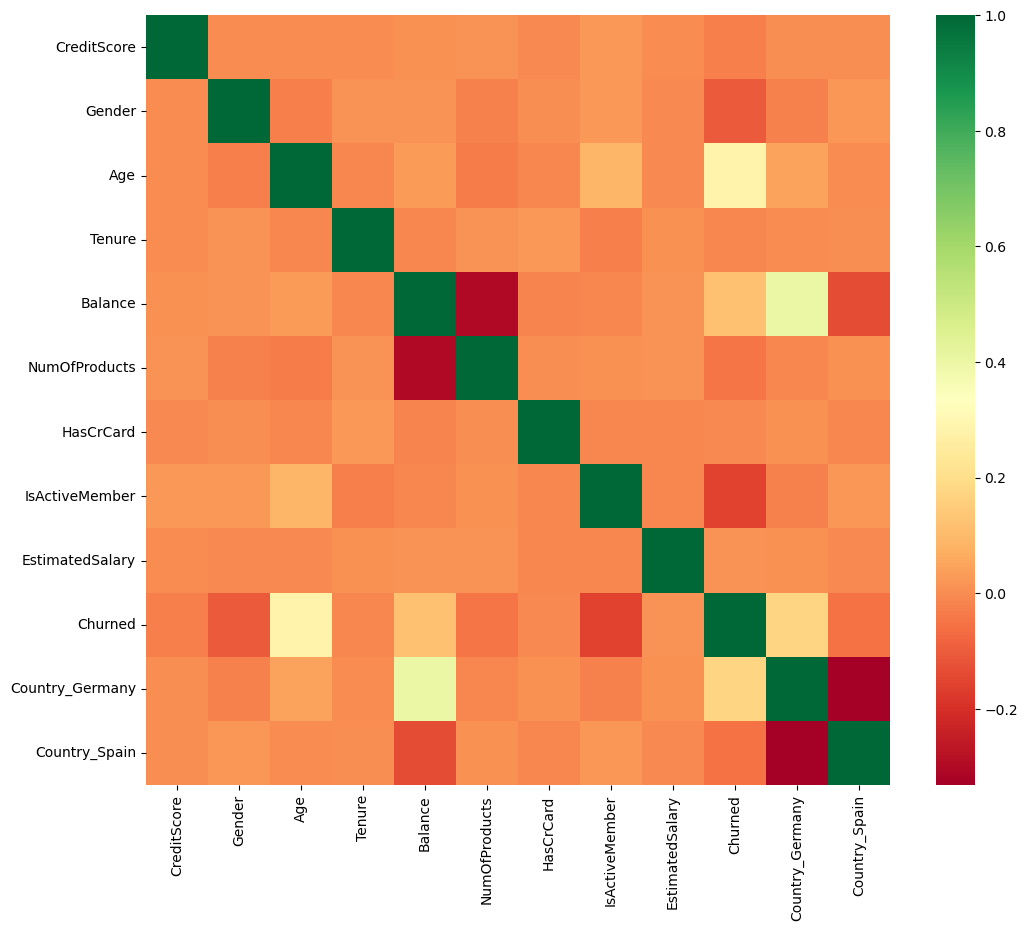

In [21]:
plt.figure(figsize=(12,10))
sns.heatmap(bank_churn.corr(), xticklabels=True, yticklabels=True, cmap='RdYlGn')

In [22]:
# Set a correlation threshold and remove unnecessary feature (if any)
threshold = 0.8

In [23]:
from collections import defaultdict

bank_churn_corr = bank_churn.corr()

flag = False

bank_churn_dict = defaultdict(list)

for row in bank_churn_corr.index:
    for col in bank_churn_corr.columns:
        if (col!=row) and (abs(bank_churn_corr.loc[row, col]) >= threshold):
            flag = True
            bank_churn_dict[row].append()

if flag:
    print('High correlation present')
    print(bank_churn_dict)
else:
    print('No high correlation present')

No high correlation present


#### 2.2 Check VIF of variables and drop necessary columns

In [25]:
# Explore Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_threshold = 5
high_vif = []

for i,k in enumerate(bank_churn.columns):
    vif = round(variance_inflation_factor(bank_churn.values, i),2)
    print(f"{i+1}. {k}: {vif}")

    if vif > vif_threshold:
        high_vif.append(k)

print("\nColumns with VIF > 5:", high_vif)

1. CreditScore: 0.15
2. Gender: 2.19
3. Age: 13.7
4. Tenure: 3.87
5. Balance: -0.0
6. NumOfProducts: 7.84
7. HasCrCard: 3.29
8. IsActiveMember: 2.15
9. EstimatedSalary: -0.0
10. Churned: 1.48
11. Country_Germany: 1.82
12. Country_Spain: 1.49

Columns with VIF > 5: ['Age', 'NumOfProducts']


In [26]:
# Drop columns where VIF > VIF threshold
bank_churn.drop(high_vif, axis=1, inplace=True)

#### 2.3 Perform train-test split of data

In [28]:
bank_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CreditScore      10000 non-null  int32
 1   Gender           10000 non-null  int32
 2   Tenure           10000 non-null  int32
 3   Balance          10000 non-null  int32
 4   HasCrCard        10000 non-null  int32
 5   IsActiveMember   10000 non-null  int32
 6   EstimatedSalary  10000 non-null  int32
 7   Churned          10000 non-null  int32
 8   Country_Germany  10000 non-null  int32
 9   Country_Spain    10000 non-null  int32
dtypes: int32(10)
memory usage: 390.8 KB


In [29]:
# Set "Churned" as target feature and the rest as input features

x = bank_churn.drop(columns='Churned', axis=1)
y = bank_churn['Churned']

In [30]:
# Scale the input features
sc = StandardScaler()

scale_cols = x.columns
x[scale_cols] = sc.fit_transform(x[scale_cols])

In [31]:
# Split the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

print("Train dataset: {0}-{1}".format(x_train.shape, y_train.shape))
print("Test dataset: {0}-{1}".format(x_test.shape, y_test.shape))

Train dataset: (7000, 9)-(7000,)
Test dataset: (3000, 9)-(3000,)


### Step 3: Train and Finetune the Models [15 marks]

#### 3.1 Model 1 - Create Classification Model

In [34]:
# Model Building
# Create an instance of a classification model (e.g. LogisticRegression, DecisionTreeClassifier etc)
lr = LogisticRegression()

In [35]:
# Fit the model on training datasets
lr.fit(x_train, y_train)

LogisticRegression()

In [36]:
# Compute predictions on training and testing sets
y_fit = lr.predict(x_train)
y_pred = lr.predict(x_test)

In [37]:
# Evaluate the model using suitable metrics (e.g. accuracy, F1 score etc)

print("Classfication Report: ")
print(classification_report(y_test, y_pred))

Classfication Report: 
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      2416
           1       0.37      0.03      0.06       584

    accuracy                           0.80      3000
   macro avg       0.59      0.51      0.47      3000
weighted avg       0.72      0.80      0.73      3000



#### 3.2 Model 2 - Create Logit model using statsmodel

In [39]:
# Prepare data for statsmodel
import statsmodels.api as sm

x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
x_train.head()

,const,CreditScore,Gender,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Country_Germany,Country_Spain
9069,1.0,-0.326221,-1.095988,-0.350204,1.585414,0.646092,0.970243,1.264220,-0.578736,1.742740
2603,1.0,-0.077899,-1.095988,0.687130,1.345327,-1.547768,0.970243,1.537940,1.727904,-0.573809
7738,1.0,-0.926334,0.912419,0.341352,-1.225847,-1.547768,-1.030670,1.279661,-0.578736,-0.573809
1579,1.0,-0.336568,0.912419,1.032908,-0.621591,0.646092,0.970243,1.663871,1.727904,-0.573809
5058,1.0,0.656722,0.912419,1.378686,1.153642,-1.547768,0.970243,0.890147,-0.578736,-0.573809


In [40]:
# Build Logit model using data and display summary results

model = sm.Logit(y_train, x_train)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.476634
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Churned   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6990
Method:                           MLE   Df Model:                            9
Date:                Thu, 09 Jan 2025   Pseudo R-squ.:                 0.06674
Time:                        10:53:48   Log-Likelihood:                -3336.4
converged:                       True   LL-Null:                       -3575.0
Covariance Type:            nonrobust   LLR p-value:                 4.325e-97
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.4582      0.032    -44.882      0.000      -1.522      -1.395
CreditScore        -0.0775      0.031     -2.534      0.011      -0.137      -0.018
Gender             -0.2725      0.031     -8.925      0.000      -0.332      -0.213
Tenure             -0.0572      0.031     -1.869      0.062      -0.117       0.003
Balance             0.1818      0.035      5.245      0.000       0.114       0.250
HasCrCard          -0.0462      0.030     -1.524      0.127      -0.106       0.013
IsActiveMember     -0.3928      0.031    -12.599      0.000      -0.454      -0.332
EstimatedSalary     0.0032      0.031      0.106      0.916      -0.057       0.063
Country_Germany     0.3324      0.033     10.182      0.000       0.268       0.396
Country_Spain       0.0415      0.034      1.211      0.226      -0.026       0.109
===================================================================================
"""

#### 3.3 Drop variables with high p-values

In [42]:
# Identify variables with high p-value (>0.05)
p_values = pd.DataFrame(result.pvalues).reset_index()
p_values = p_values.rename(columns={'index': 'Features', 0: 'p-value'})

alpha = 0.05

# Create a list of dropped columns
drop_pval = list(p_values[p_values['p-value'] > alpha]['Features'])

if len(drop_pval) != 0:
    print("Columns dropping: {}".format(drop_pval))
else:
    print("No columns to drop.")

Columns dropping: ['Tenure', 'HasCrCard', 'EstimatedSalary', 'Country_Spain']


In [43]:
# Drop variables with high p-value
new_x_train = x_train.drop(columns=drop_pval, axis=1)
new_x_test = x_test.drop(columns=drop_pval, axis=1)

In [44]:
print(new_x_train.shape)
print(new_x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7000, 6)
(3000, 6)
(7000,)
(3000,)


#### 3.4 Create a second classification model using updated data

In [46]:
new_x_train = sm.add_constant(new_x_train)
new_x_test = sm.add_constant(new_x_test)

In [47]:
# Create second instance of selected classification model using updated data
new_model = sm.Logit(y_train, new_x_train)
new_result = new_model.fit()
new_result.summary()

Optimization terminated successfully.
         Current function value: 0.477158
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                Churned   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6994
Method:                           MLE   Df Model:                            5
Date:                Thu, 09 Jan 2025   Pseudo R-squ.:                 0.06572
Time:                        10:53:48   Log-Likelihood:                -3340.1
converged:                       True   LL-Null:                       -3575.0
Covariance Type:            nonrobust   LLR p-value:                 2.518e-99
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.4551      0.032    -44.899      0.000      -1.519      -1.392
CreditScore        -0.0763      0.031     -2.498      0.012      -0.136      -0.016
Gender             -0.2727      0.031     -8.941      0.000      -0.333      -0.213
Balance             0.1819      0.035      5.254      0.000       0.114       0.250
IsActiveMember     -0.3896      0.031    -12.518      0.000      -0.451      -0.329
Country_Germany     0.3174      0.031     10.393      0.000       0.258       0.377
===================================================================================
"""

In [48]:
len(new_result.params)

6

In [49]:
# Compute predictions on training and testing sets
new_y_pred = new_model.predict(params=new_result.params, exog=new_x_test)
print("Predictions: ", new_y_pred)

Predictions:  [0.34255628 0.07821412 0.24562428 ... 0.09566841 0.0806971  0.50026389]


In [50]:
# Evaluate the second model using suitable metrics (e.g. accuracy, F1 score etc)
new_y_pred_binary = (new_y_pred >=0.5).astype(int)
print("Accuracy Score: ", accuracy_score(y_test, new_y_pred_binary))

Accuracy Score:  0.8


### Step 4: Perform Model Validation and Evaluation [5 marks]

#### 4.1 Check model performance using cross validation

In [53]:
# Perform K-fold cross validation on second classification model
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, new_x_train, y_train, cv=5, scoring='f1')
scores

array([0.0625    , 0.05128205, 0.06389776, 0.03333333, 0.03367003])

In [54]:
# Display mean training accuracy of cross validation
scores.mean()

0.04893663637273861

In [55]:
# Display standard deviation of training accuracy of cross validation
scores.std()

0.01334041494904959

#### 4.2 Evaluate model performance using Confusion Matrix

In [57]:
# Generate Confusion Matrix
new_y_pred_labels = (new_y_pred > 0.5).astype(int)
new_y_pred_labels

array([0, 0, 0, ..., 0, 0, 1])

In [58]:
# Display metrics used for model evaluation based on Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, new_y_pred_labels))

Confusion Matrix:
[[2383   33]
 [ 567   17]]


In [59]:
accuracy = accuracy_score(y_test, new_y_pred_labels)
precision = precision_score(y_test, new_y_pred_labels)
recall = recall_score(y_test, new_y_pred_labels)
f1 = f1_score(y_test, new_y_pred_labels)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.8
Precision: 0.34
Recall: 0.02910958904109589
F1-Score: 0.05362776025236593


Text(0.5, 23.52222222222222, 'Predicted Label')

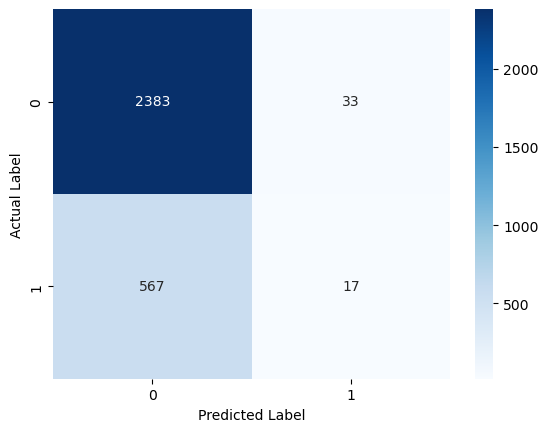

In [60]:
sns.heatmap(confusion_matrix(y_test, new_y_pred_labels), annot=True, cmap='Blues', fmt='g')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

### What is the issue with your current model?

### Step 5: Recommend possible steps to enhance your model performance. [5 marks]

#### List of recommendations

1. It has a high value of 567 missed churners. For this, we can lower the threshold which will then increase the likelihood of identifying potential churners, even if it means to reduce precision. The goal is to catch more churners, which is important for banks that will costly for them if not identified.

2. Accuracy score is given to be 0.8, which can be further improve by improving on recall score, back to the first point.

3.  

End of Document